# Import libraries

In [1]:
#for visualization

import matplotlib.pyplot as plt
import imageio
import matplotlib.image as img
from tensorflow.keras.preprocessing import image
import numpy as np
#read image path

import pathlib
from pathlib import Path


#for image processing

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
#for model

import tensorflow as tf
from tensorflow.keras import Sequential
from keras.layers import *

#for warnings
import warnings
warnings.filterwarnings("ignore")

# Read Data

In [2]:
#read data path
df_path=pathlib.Path('/kaggle/input/vehicle-classification/Vehicles')

In [3]:
image_class=os.listdir('/kaggle/input/vehicle-classification/Vehicles')
image_class

['Ships', 'Cars', 'Motorcycles', 'Bikes', 'Trains', 'Auto Rickshaws', 'Planes']

# Visualize Data

In [4]:
def plot_images(image_class):
    plt.figure(figsize=(14 ,14))
    for i , category in enumerate(image_class):
        image_path = df_path / category
        image_in_folder = os.listdir(image_path)
        
        first_image=image_in_folder[0]
        first_image_path=image_path  / first_image
        
        img = image.load_img(first_image_path)
        img_array=image.img_to_array(img)/255
        
        plt.subplot(4 , 4 , i+1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    plt.show()

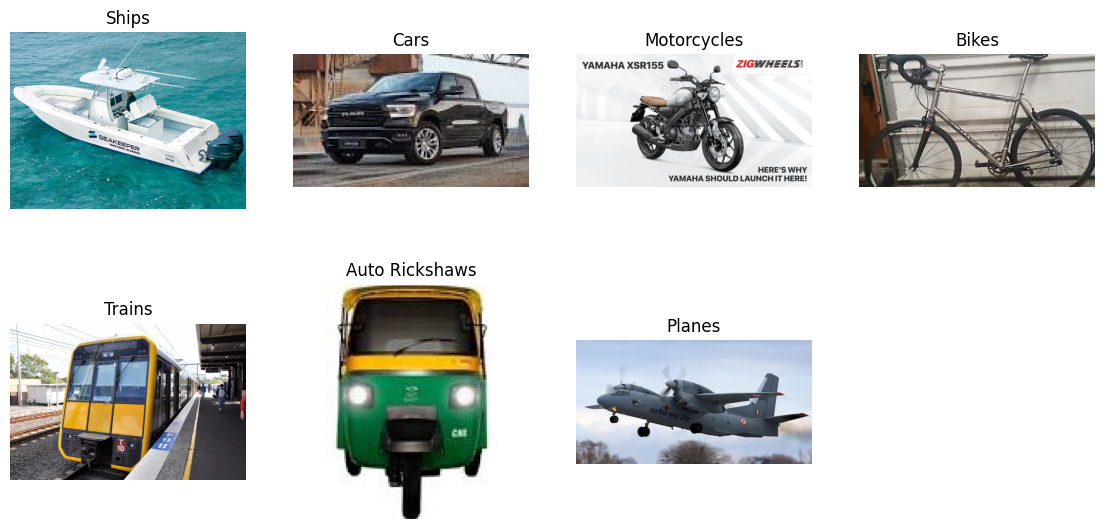

In [5]:
plot_images(image_class)

# Image Preprocessing

In [6]:
image_generator = ImageDataGenerator(rescale = 1/255 , validation_split=0.2)

In [7]:
train_data=image_generator.flow_from_directory('/kaggle/input/vehicle-classification/Vehicles',
                                             target_size=(224,224),
                                             batch_size=32,
                                             class_mode='categorical',
                                             shuffle=True,
                                             subset='training')

Found 4470 images belonging to 7 classes.


In [8]:
test_data=image_generator.flow_from_directory('/kaggle/input/vehicle-classification/Vehicles',
                                             target_size=(224,224),
                                             batch_size=1,
                                             class_mode='categorical',
                                             shuffle=True,
                                             subset='validation')

Found 1117 images belonging to 7 classes.


# CNN Model building

In [9]:
model=Sequential()

In [10]:
# Clear session
from tensorflow.keras import backend as K
K.clear_session()

# Rebuild the model with the correct input size
model = Sequential()
#convolutional layer 
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[224, 224, 3]))
#pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))
#convolutional layer
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
#pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add Flatten
model.add(Flatten())
#Fully Connected layer 
model.add(Dense(128, activation='relu'))
model.add(Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
model_history=model.fit(train_data, epochs=5, validation_data=test_data)


Epoch 1/5


I0000 00:00:1725982578.579260      81 service.cc:145] XLA service 0x7b1dd00057e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725982578.579348      81 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  1/140 ━━━━━━━━━━━━━━━━━━━━ 20:46 9s/step - accuracy: 0.1250 - loss: 1.9784

I0000 00:00:1725982582.363318      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 91s 592ms/step - accuracy: 0.4478 - loss: 2.1345 - val_accuracy: 0.7422 - val_loss: 0.7684
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 294ms/step - accuracy: 0.8645 - loss: 0.4395 - val_accuracy: 0.8004 - val_loss: 0.6456
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - accuracy: 0.9639 - loss: 0.1311 - val_accuracy: 0.7744 - val_loss: 0.7684
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 299ms/step - accuracy: 0.9894 - loss: 0.0403 - val_accuracy: 0.8102 - val_loss: 0.7903
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 307ms/step - accuracy: 0.9990 - loss: 0.0106 - val_accuracy: 0.8156 - val_loss: 0.8741


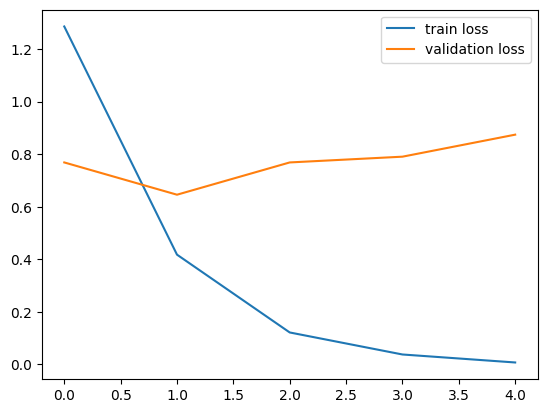

In [11]:
plt.plot(model_history.history['loss'],label='train loss')
plt.plot(model_history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

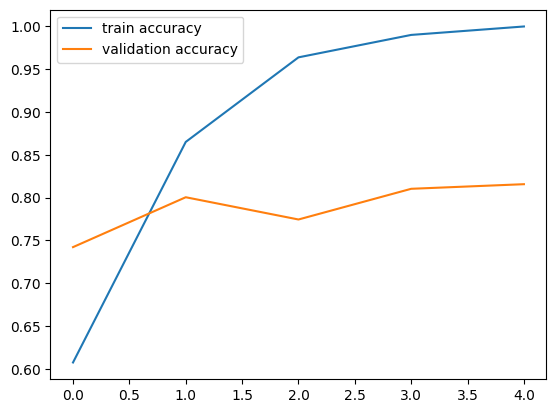

In [12]:
plt.plot(model_history.history['accuracy'],label='train accuracy')
plt.plot(model_history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

In [13]:
model.evaluate(train_data)


140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 1.0000 - loss: 0.0018


[0.0017489235615357757, 1.0]

In [14]:
model.evaluate(test_data)


1117/1117 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8249 - loss: 0.8053


[0.8741453289985657, 0.8155774474143982]